# Analysis of Colors in Popular English Romance Movies

## Project Goals: The Colors of Romance

### Introduction
The Colors of Romance project aims to explore the relationship between color palettes and the emotional tone of romance movies across different languages. By analyzing the dominant colors used in popular romance films in English, Korean, Hindi, Turkish, and Japanese, this project seeks to uncover whether the language and cultural context influence the color schemes associated with love and romance.

### Whats already done:
**Data Collection:**
Extract frames from the top 25 romance movies in each language category.
Identify the dominant colors in each frame using a consistent methodology.

**Data Organization:**
Store the dominant color data for each movie in separate CSV files, with each file corresponding to one movie.

### What's left to do:

**Color Analysis:**
Perform clustering analysis (e.g., K-Means in this notebook) to identify common color patterns within and across language categories. Compare the color palettes across different languages to see if there are significant differences in how romance is visually represented.

**Visualization:**
Create visual representations (e.g., color histograms, cluster visualizations) to illustrate the dominant colors and patterns found in the analysis.

**Interpretation:**
Interpret the results to draw conclusions about the influence of language and cultural context on the color choices in romance films. Explore whether certain color palettes are more prevalent in one language category compared to others.

**Reporting:**
Document the findings in a comprehensive report, supported by visualizations and statistical analysis.
Discuss potential implications for film studies, cultural analysis, and color theory.

## Imports

In [2]:
import pandas as pd
import os
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
from mpl_toolkits.mplot3d import Axes3D
import numpy as np
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
from IPython.display import display, HTML 
import matplotlib.colors as mcolors
import math
from collections import Counter

## Loading the Datasets

In [3]:

# Path to the directory containing the CSV files
directory_path = '/Users/rsudhir/Documents/GitHub/Data-Science-Project---Colors-Of-Romance/English-Analysis/English-Movie-CSVs'

# List to hold each DataFrame
dfs = []

# Loop through the files in the directory and load each CSV
for i in range(1, 26):
    file_path = os.path.join(directory_path, f'{i}.csv')
    df = pd.read_csv(file_path)
    # Drop columns with NaN values
    df = df.drop(columns=['color_10_r', 'color_10_g', 'color_10_b'])
    
    # Add a column to indicate which movie the data is from
    df['movie_id'] = i
    
    dfs.append(df)

# Combine all DataFrames into a single DataFrame
combined_df = pd.concat(dfs, ignore_index=True)

# Display the combined DataFrame to ensure it looks correct
display(combined_df.head())


,frame_path,color_1_r,color_1_g,color_1_b,color_2_r,color_2_g,color_2_b,color_3_r,color_3_g,color_3_b,...,color_7_r,color_7_g,color_7_b,color_8_r,color_8_g,color_8_b,color_9_r,color_9_g,color_9_b,movie_id
0,output_0000001.png,94,76,59,210,190,185,28,24,21,...,58,26,24,169,174,174,163,160,165,1
1,output_0000002.png,38,36,28,191,177,178,129,114,101,...,164,132,118,156,148,156,100,88,100,1
2,output_0000003.png,126,109,90,28,24,19,196,180,163,...,170,168,165,178,180,163,71,63,34,1
3,output_0000004.png,41,32,30,94,81,72,105,100,90,...,155,156,154,83,89,101,152,148,156,1
4,output_0000005.png,32,27,26,196,174,161,121,93,80,...,119,130,150,148,148,140,73,77,96,1


## Initial Visualization

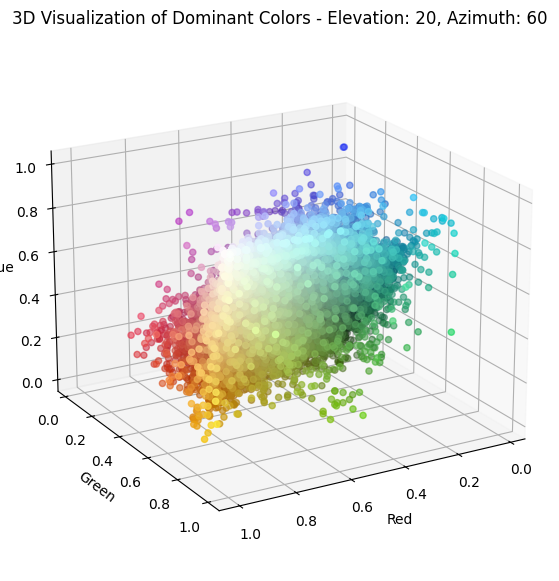

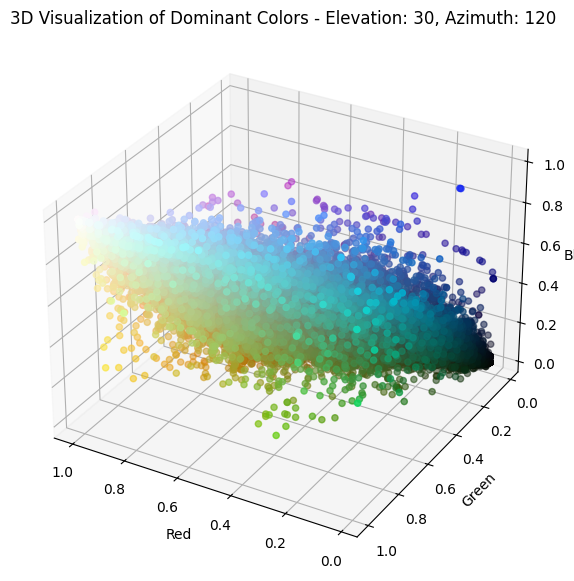

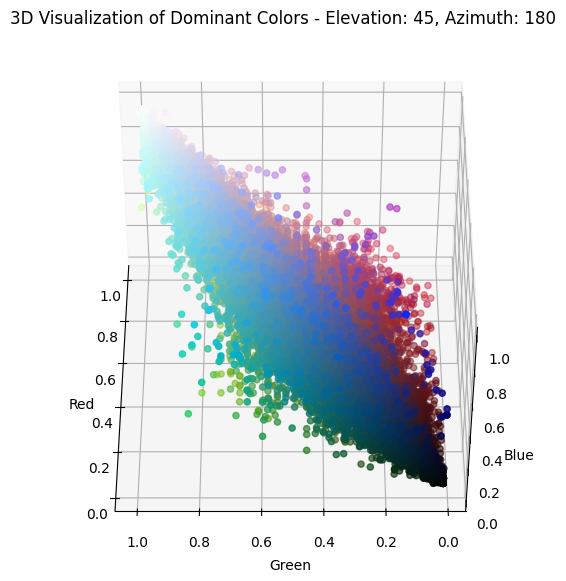

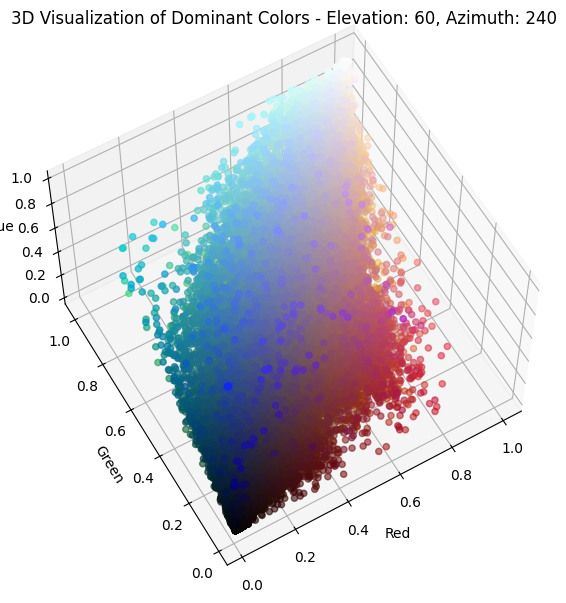

In [4]:
# Create a list of angles to view from
angles = [(20, 60), (30, 120), (45, 180), (60, 240)]

# Extract the RGB values for all 9 dominant colors
r = combined_df[['color_1_r', 'color_2_r', 'color_3_r', 'color_4_r', 'color_5_r', 'color_6_r', 'color_7_r', 'color_8_r', 'color_9_r']].values.flatten()
g = combined_df[['color_1_g', 'color_2_g', 'color_3_g', 'color_4_g', 'color_5_g', 'color_6_g', 'color_7_g', 'color_8_g', 'color_9_g']].values.flatten()
b = combined_df[['color_1_b', 'color_2_b', 'color_3_b', 'color_4_b', 'color_5_b', 'color_6_b', 'color_7_b', 'color_8_b', 'color_9_b']].values.flatten()

# Normalize RGB values and clip to ensure they are within [0, 1]
r_normalized = np.clip(r / 255.0, 0, 1)
g_normalized = np.clip(g / 255.0, 0, 1)
b_normalized = np.clip(b / 255.0, 0, 1)

# Create 3D plots from different angles
for elev, azim in angles:
    fig = plt.figure(figsize=(10, 7))
    ax = fig.add_subplot(111, projection='3d')
    
    # Scatter plot
    ax.scatter(r_normalized, g_normalized, b_normalized, c=[(r_val, g_val, b_val) for r_val, g_val, b_val in zip(r_normalized, g_normalized, b_normalized)], marker='o')
    
    # Set labels
    ax.set_xlabel('Red')
    ax.set_ylabel('Green')
    ax.set_zlabel('Blue')
    
    # Set plot title
    ax.set_title(f'3D Visualization of Dominant Colors - Elevation: {elev}, Azimuth: {azim}')
    
    # Set the viewing angle
    ax.view_init(elev=elev, azim=azim)
    
    # Show the plot
    plt.show()

Hmm so from this intial plot it doesnt seem to show us anything indicative of a specific color profile being preferre, but lets not make any conclusions here.

## Dominant Color per frame plotted

Here i just want to plot the dominant color per frame for each movie just to get an idea of what colors i expect to see in the clusterings.

Also to explain, some movies have fewer frames as a result of the scene detect algorithm, which only grabs frames when theres been a significant change in the color profile between frames. Movies where this happens less often, will therefore have fewer frames.

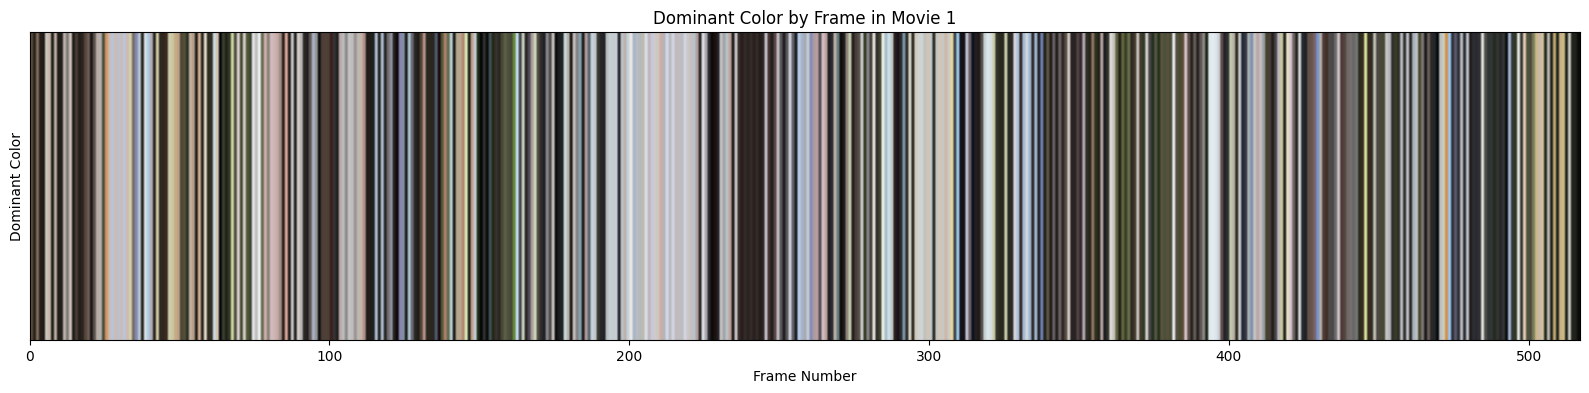

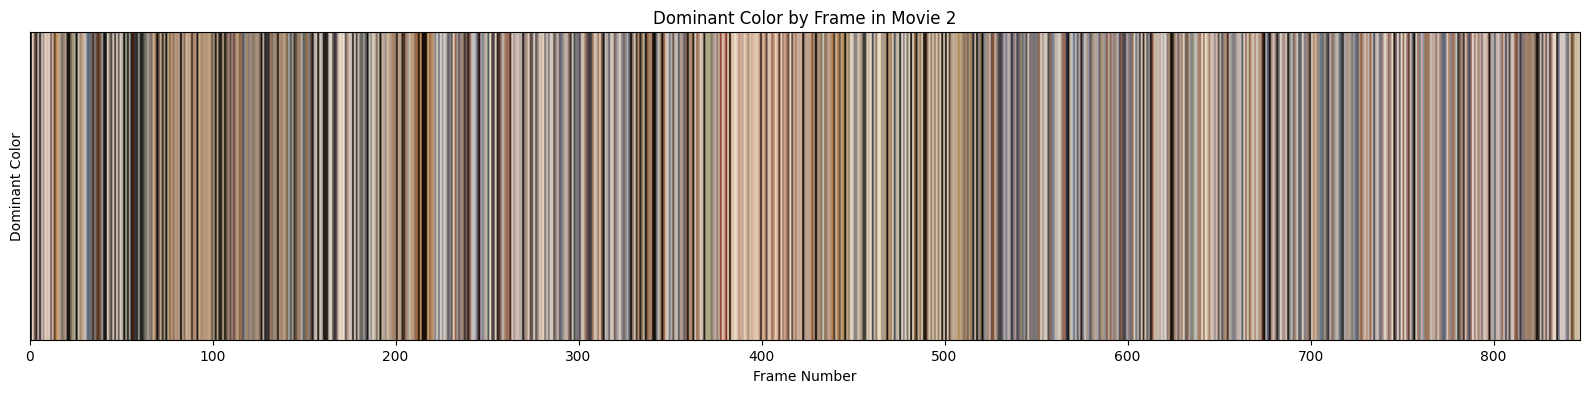

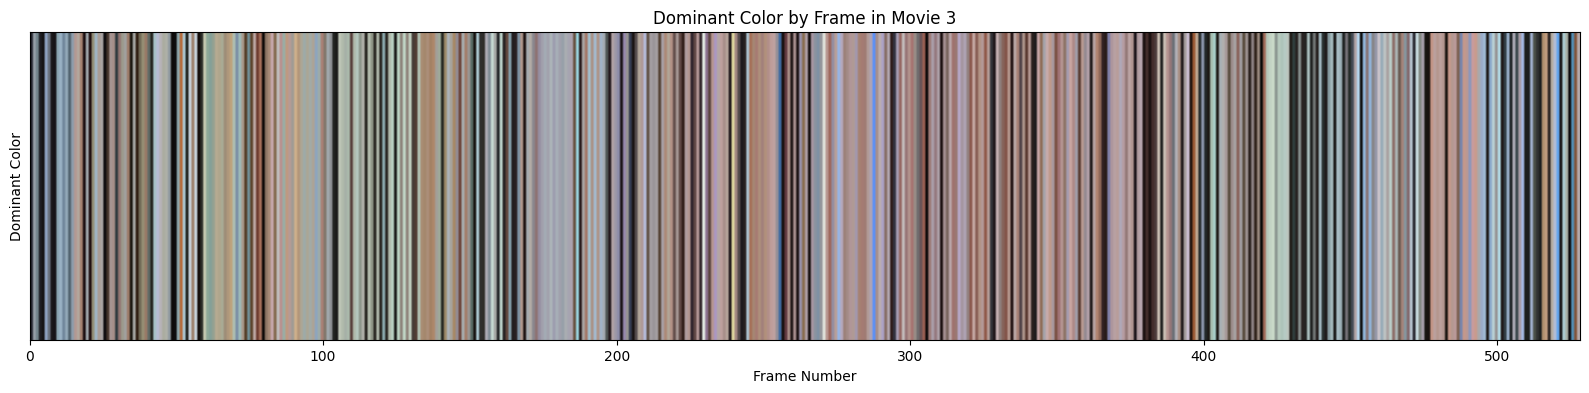

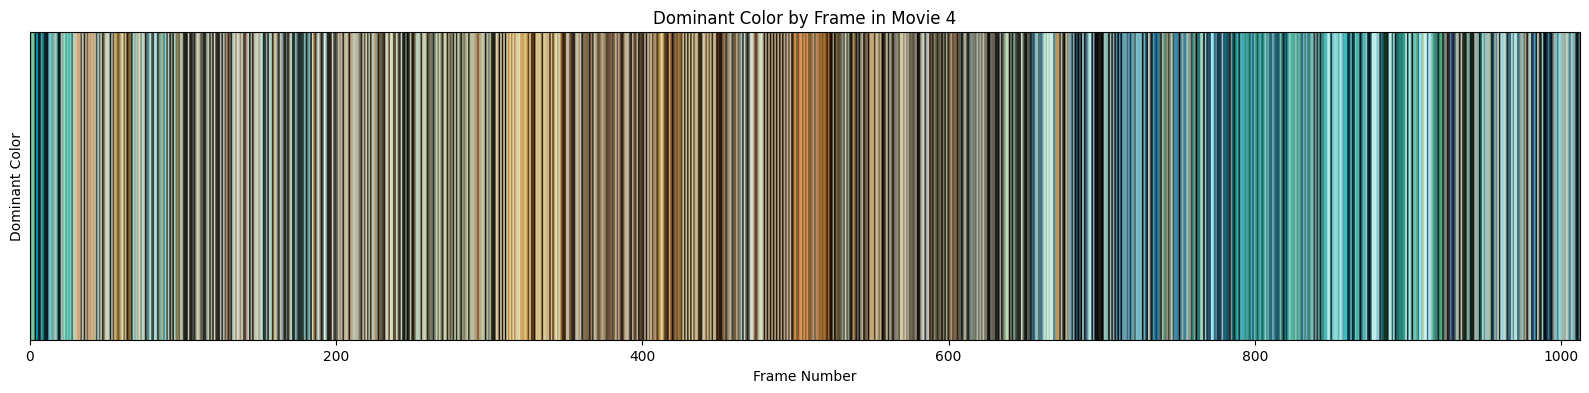

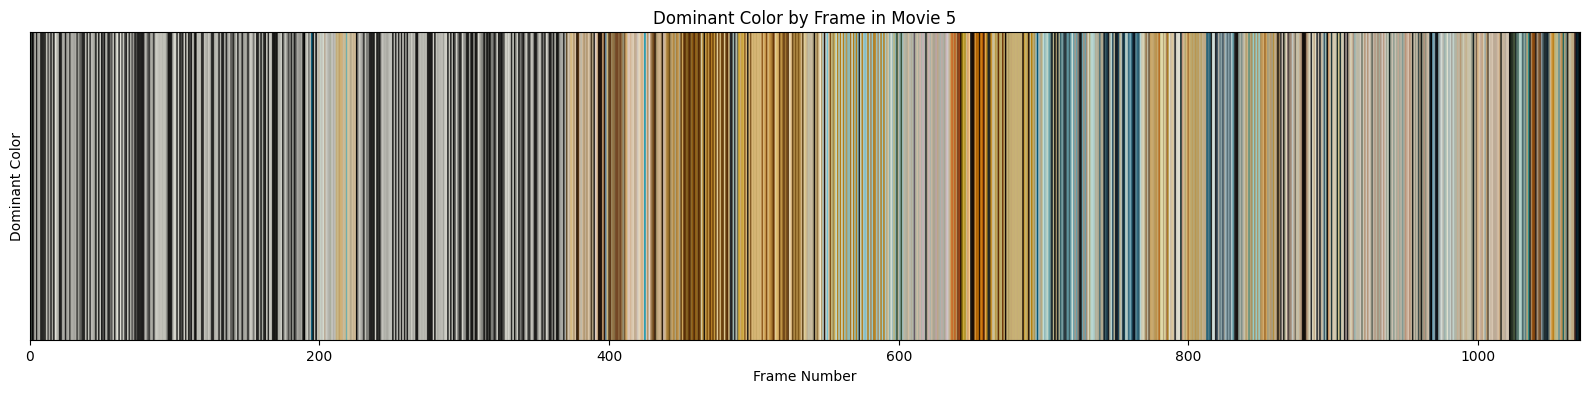

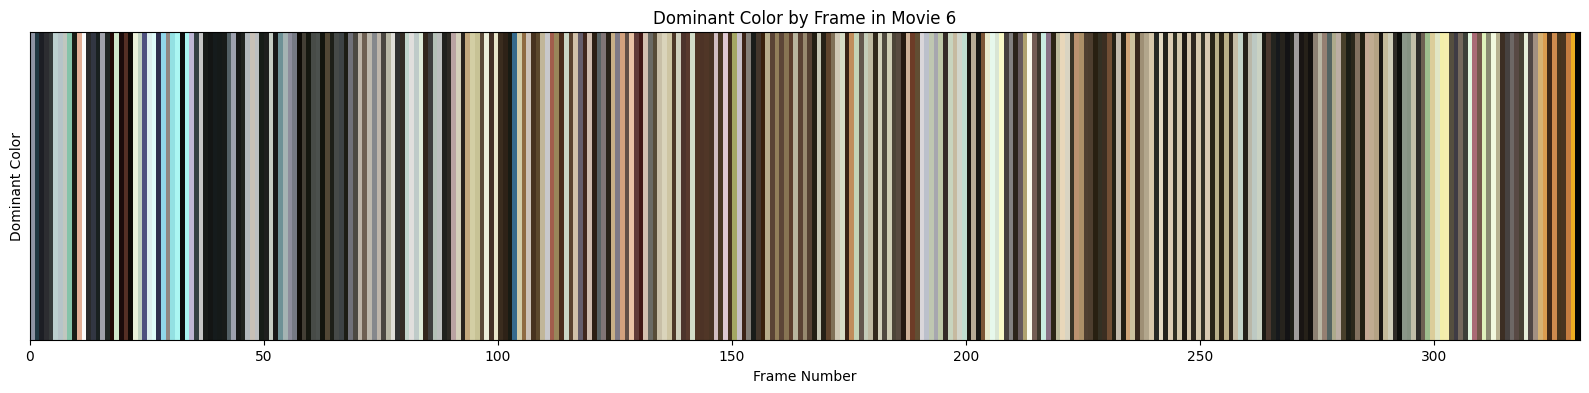

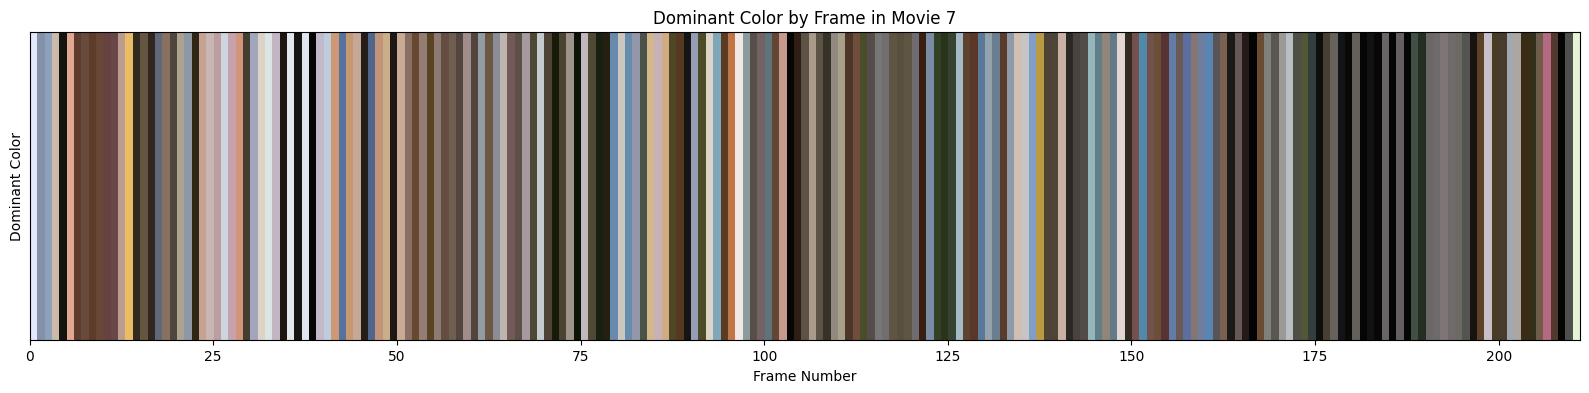

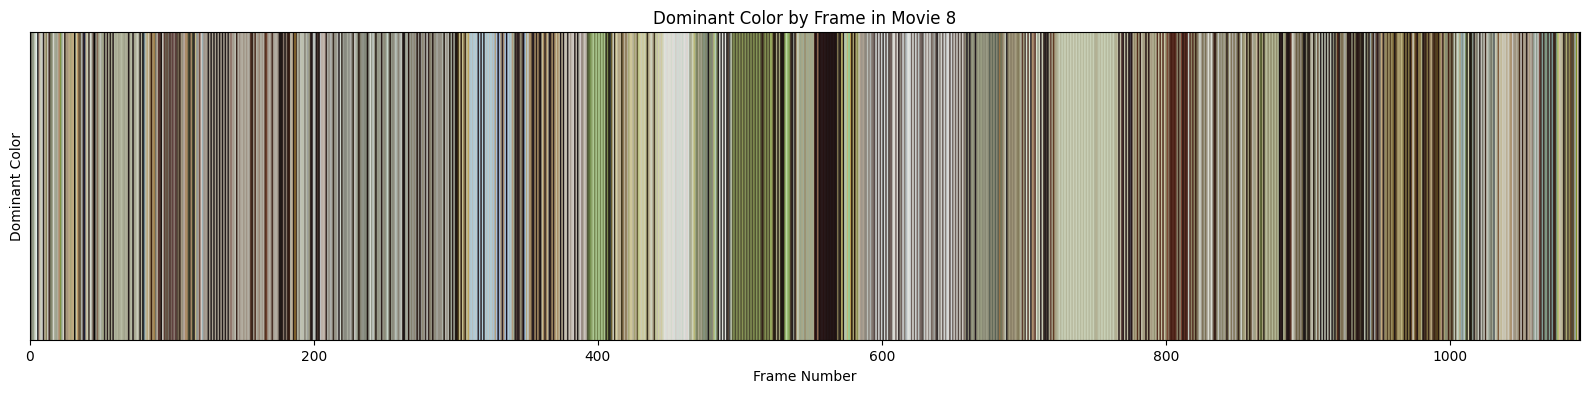

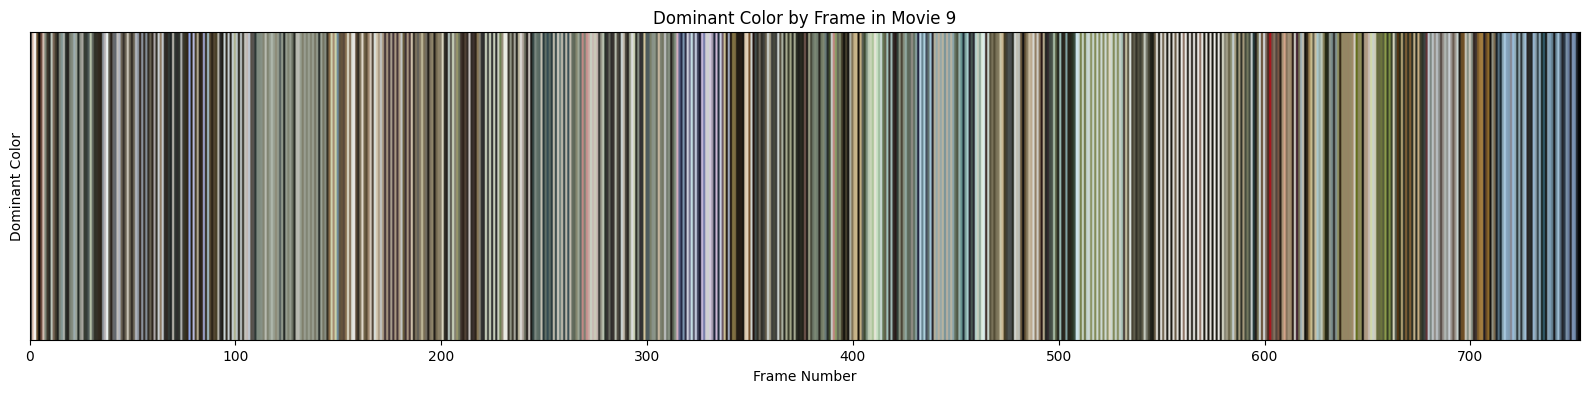

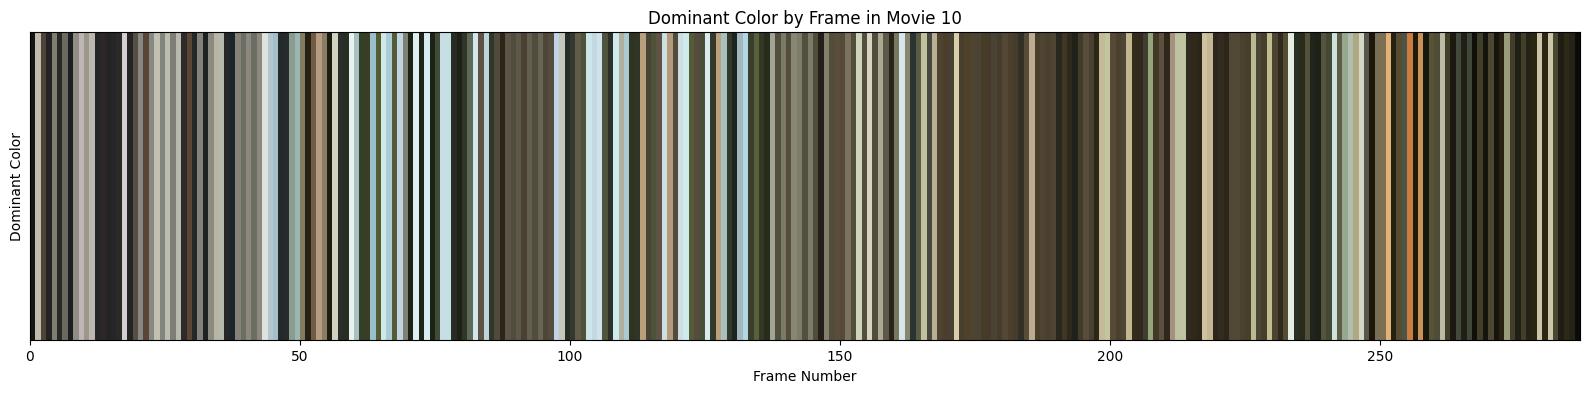

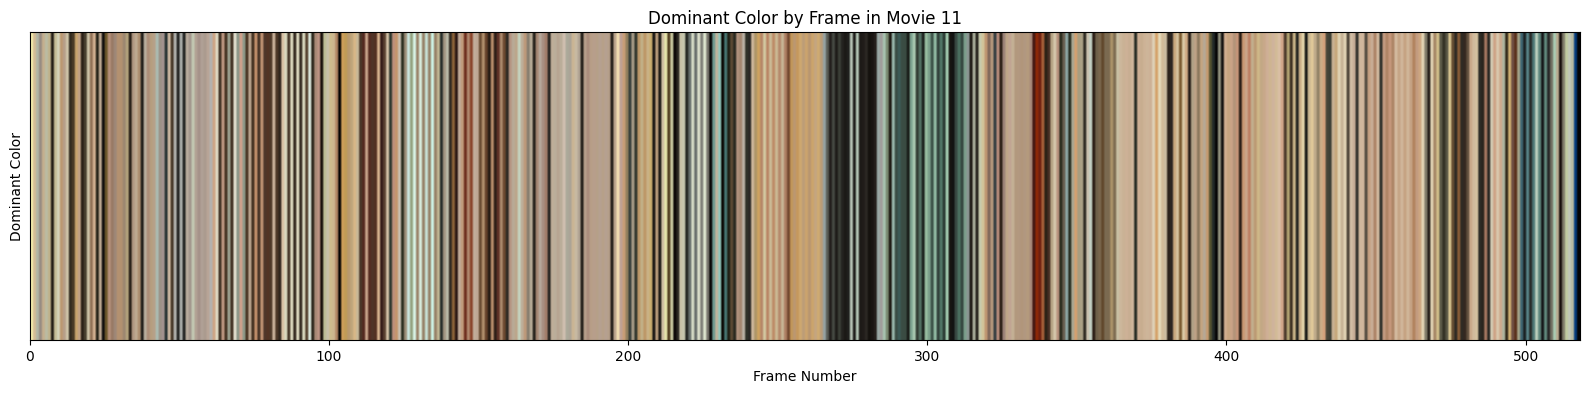

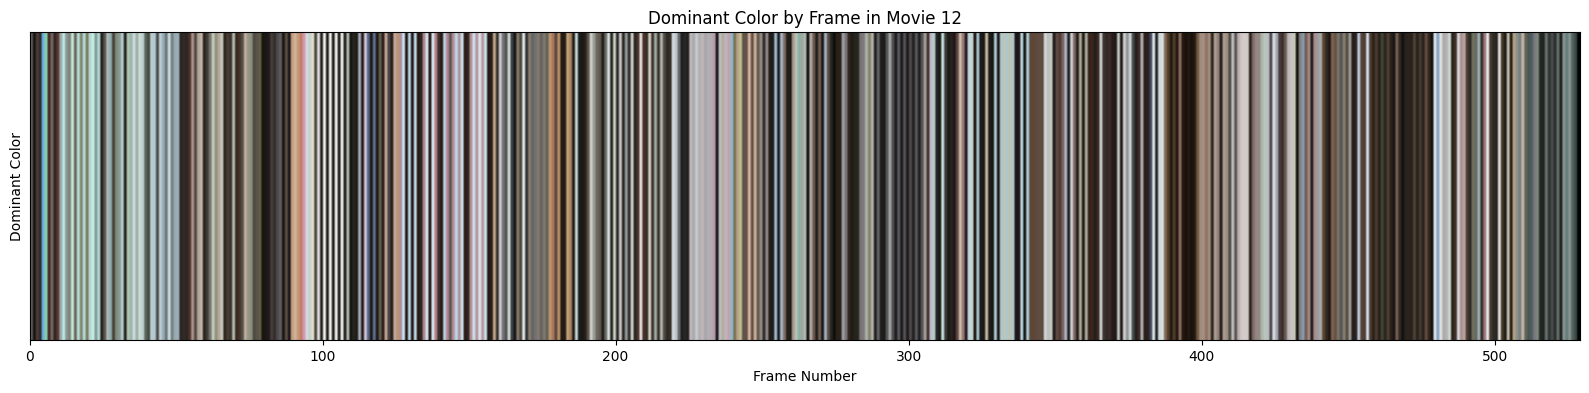

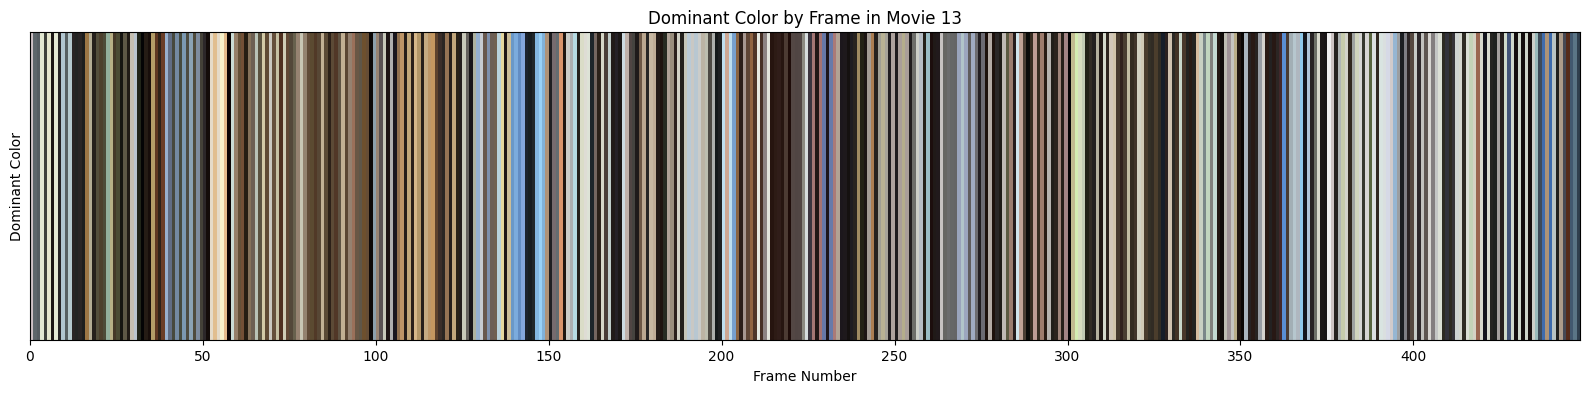

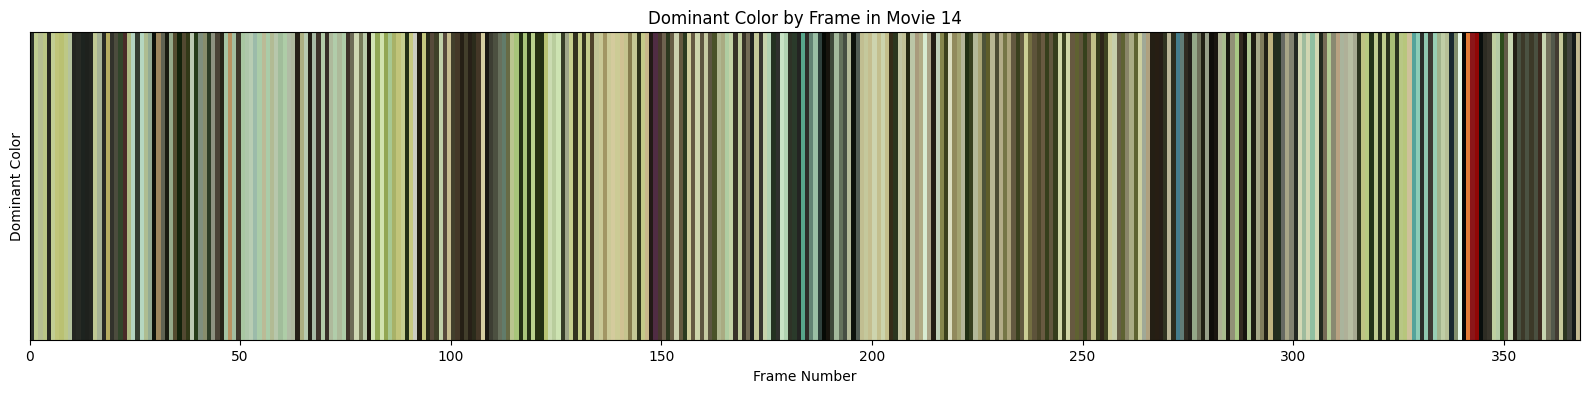

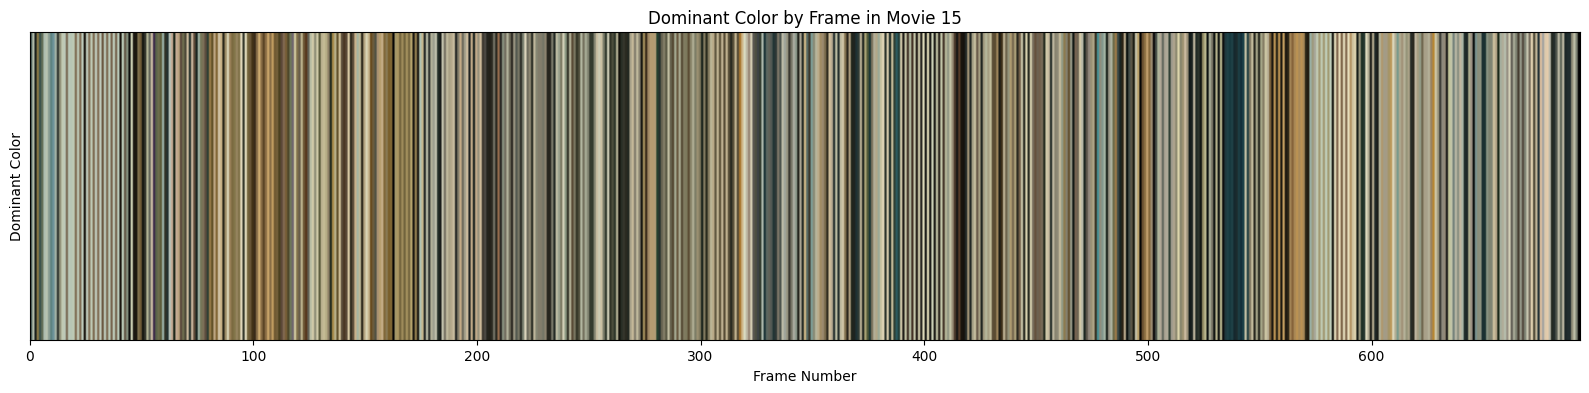

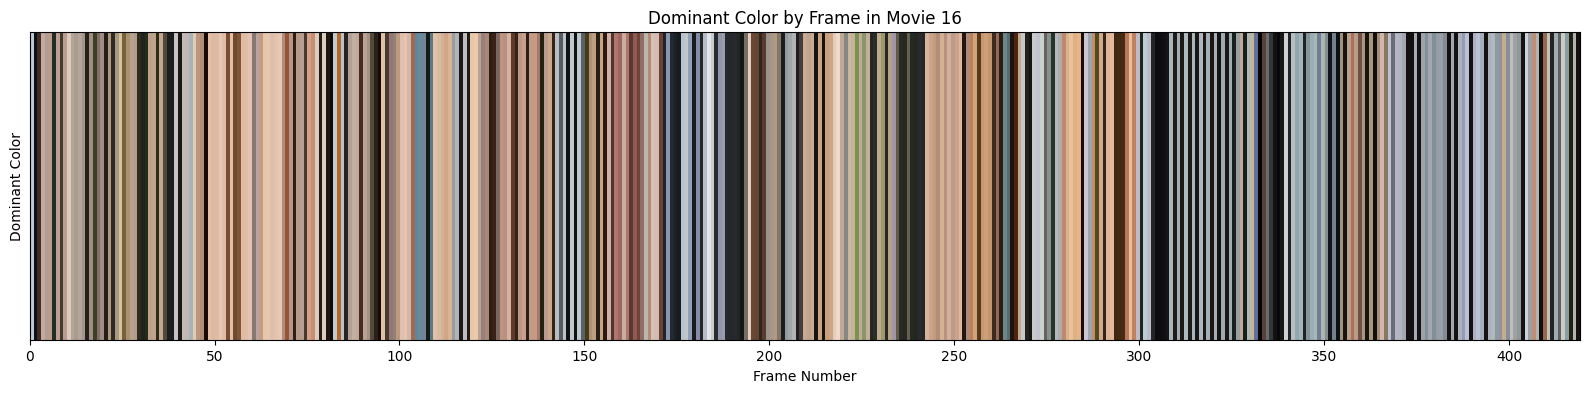

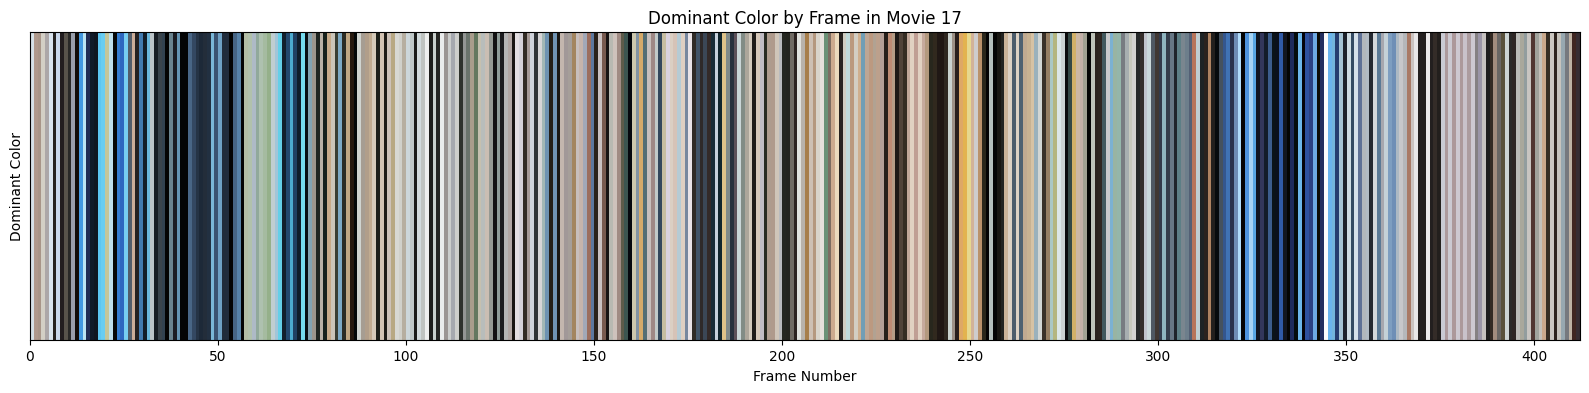

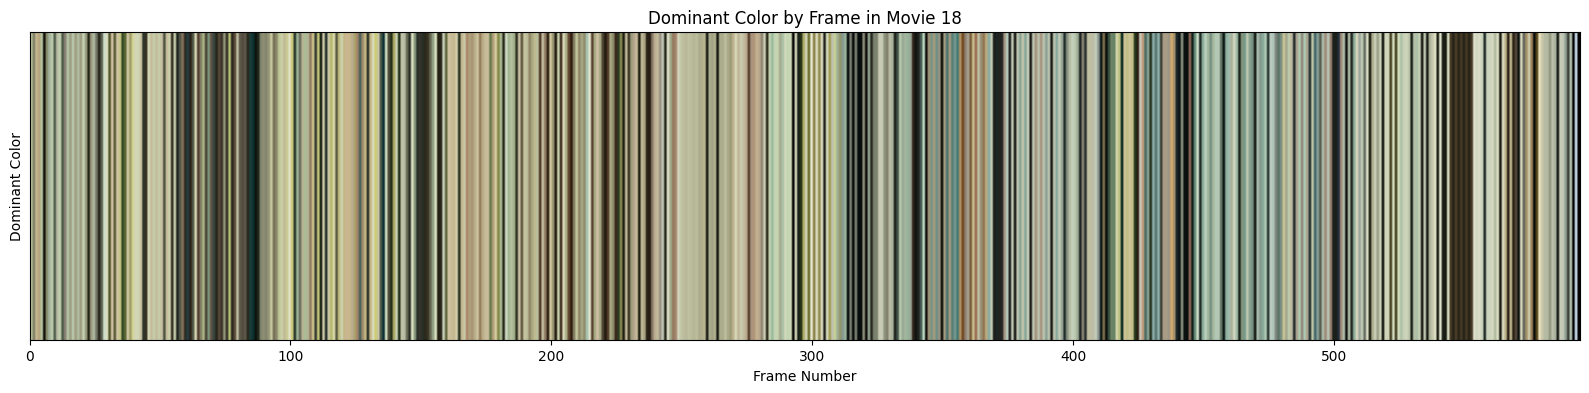

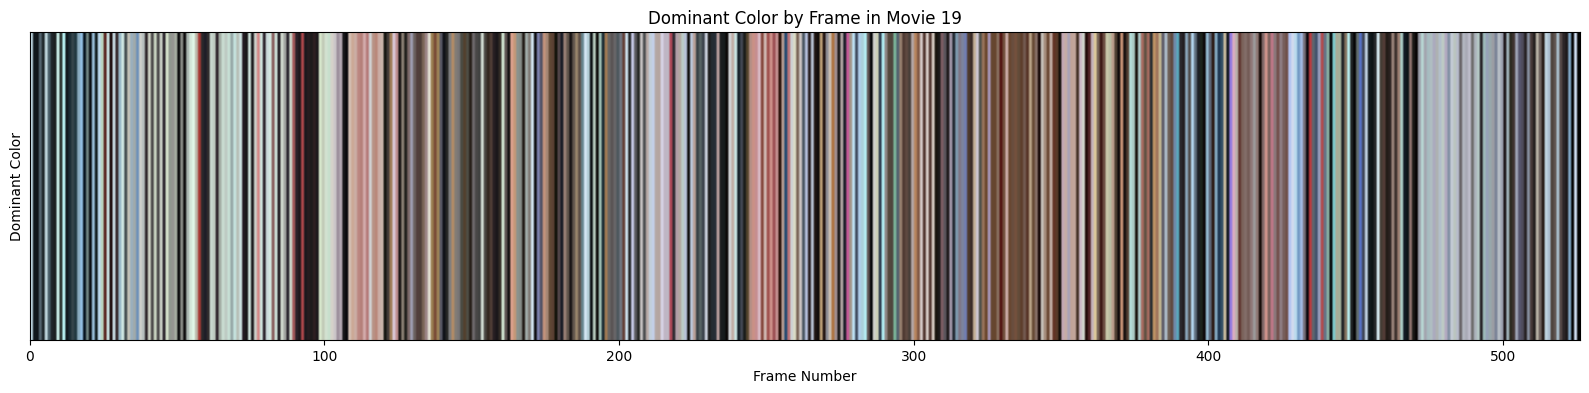

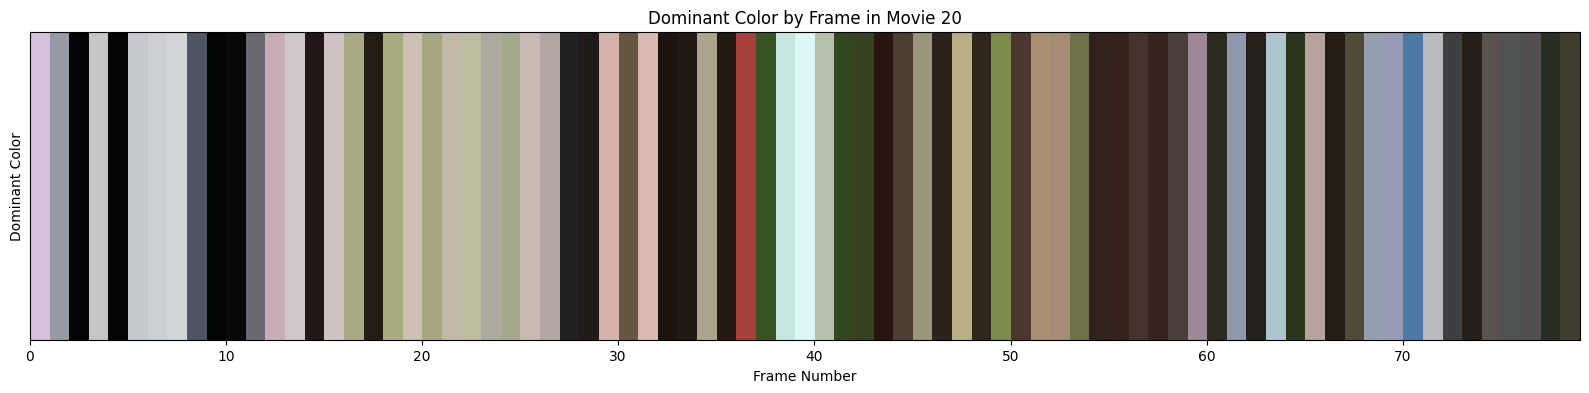

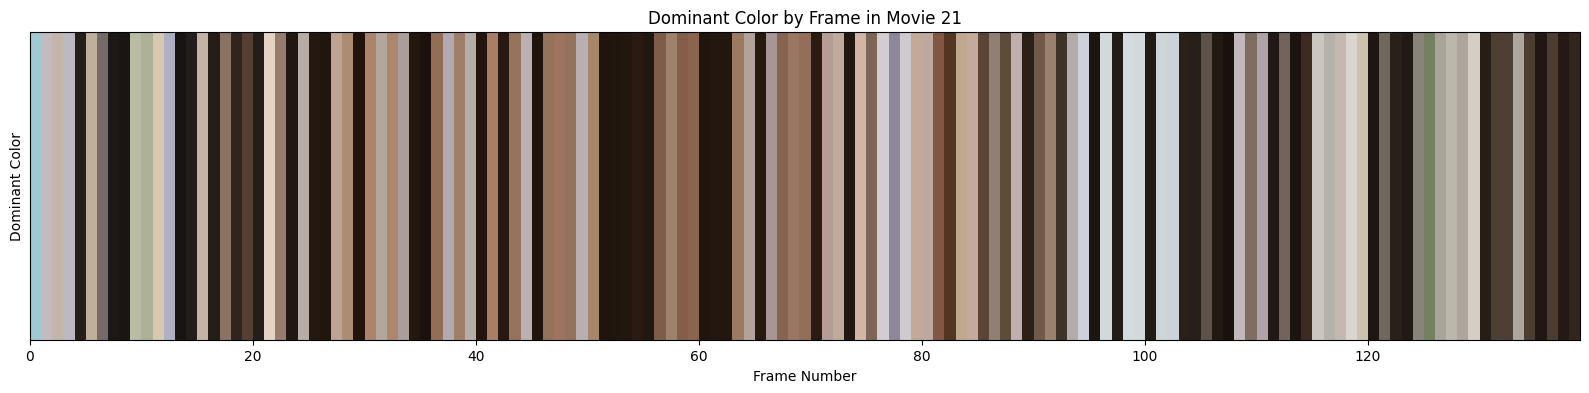

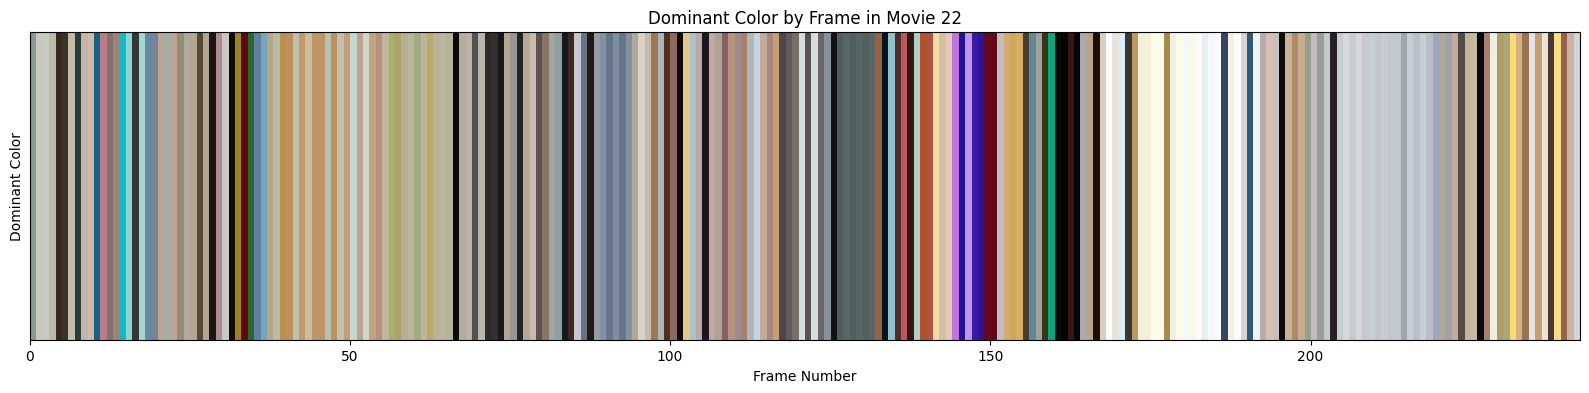

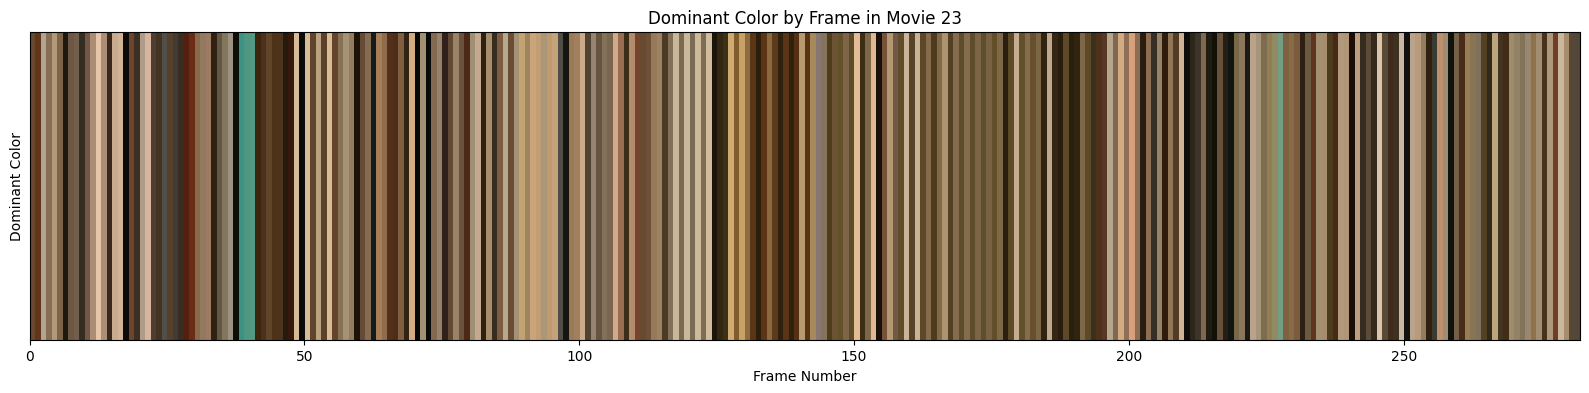

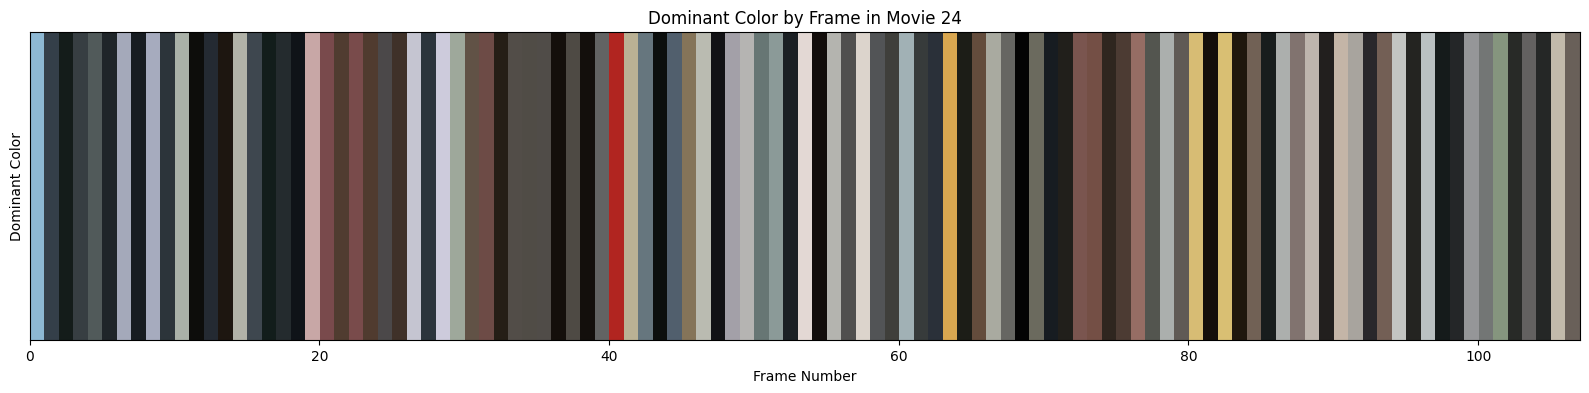

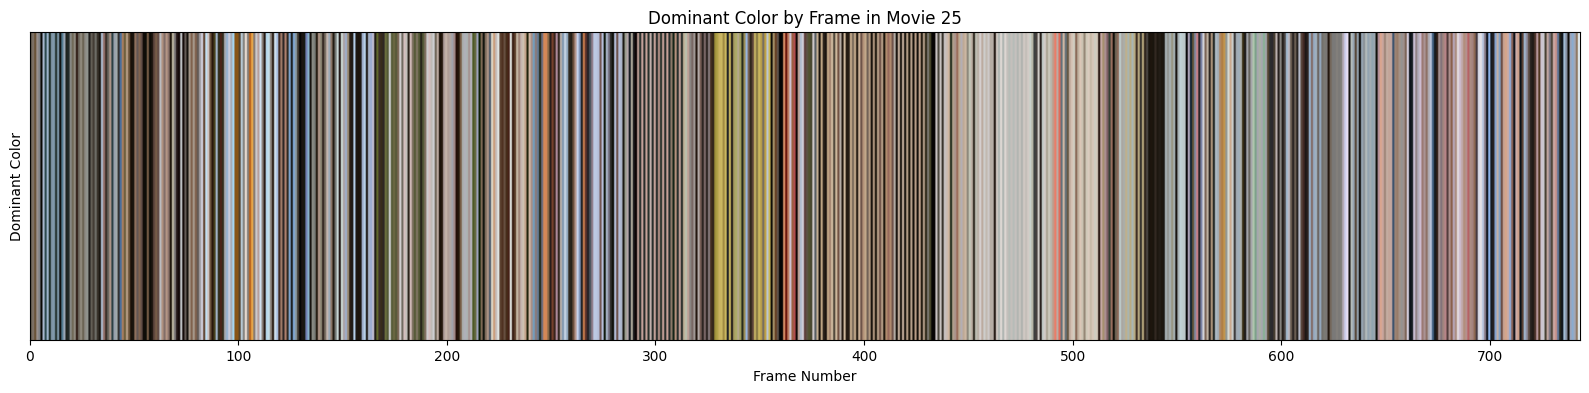

In [5]:
#loop through each movie and plot the dominant color by frame
for movie_id, movie_data in combined_df.groupby('movie_id'):
    # Extract frame numbers and dominant colors for plotting
    frame_numbers = np.arange(len(movie_data))
    dominant_colors_rgb = np.array(movie_data[['color_1_r', 'color_1_g', 'color_1_b']])
    
    # Create the heatmap
    plt.figure(figsize=(20, 4))
    plt.imshow([dominant_colors_rgb], aspect='auto', extent=[0, len(frame_numbers), 0, 1])
    plt.xlabel('Frame Number')
    plt.ylabel('Dominant Color')
    plt.title(f'Dominant Color by Frame in Movie {movie_id}')
    plt.yticks([])
    plt.show()

## K-Means Analysis

I know from the K-means analysis I did on the Ghibli project that the lower the numbers of clusters, the more muted the color of each cluster centre. As stated last time this probably has to do with it averaging more muted tones due to the reduced of clusters. So im going to choose 15 ish clusters.

### The Plan

**Step-by-Step K-Means Analysis:**

1. **Segment Each Movie into x Parts:** We are doing this to get a more diverse understanding of the colors across each movie.

2. **Cluster Colors Within Each Segment:** Apply K-Means clustering to the colors within each segment.

3. **Cluster Segment Centers for Each Movie:** Cluster the cluster centers from each segment to identify dominant color themes for the entire movie.

4. **Final Clustering Across All Movies:** Take the cluster centers from each movie and perform another round of clustering to find common color themes across all movies.

### Step 1: Cluster Colors Within Each Segment

*Segment the movies first*

In [6]:
# Define the number of segments
num_segments = 5

# Loop through each movie and create a segment ID
combined_df['segment_id'] = combined_df.groupby('movie_id').cumcount() // (combined_df.groupby('movie_id')['frame_path'].transform('count') // num_segments)

In [7]:
display(combined_df)

,frame_path,color_1_r,color_1_g,color_1_b,color_2_r,color_2_g,color_2_b,color_3_r,color_3_g,color_3_b,...,color_7_g,color_7_b,color_8_r,color_8_g,color_8_b,color_9_r,color_9_g,color_9_b,movie_id,segment_id
0,output_0000001.png,94,76,59,210,190,185,28,24,21,...,26,24,169,174,174,163,160,165,1,0
1,output_0000002.png,38,36,28,191,177,178,129,114,101,...,132,118,156,148,156,100,88,100,1,0
2,output_0000003.png,126,109,90,28,24,19,196,180,163,...,168,165,178,180,163,71,63,34,1,0
3,output_0000004.png,41,32,30,94,81,72,105,100,90,...,156,154,83,89,101,152,148,156,1,0
4,output_0000005.png,32,27,26,196,174,161,121,93,80,...,130,150,148,148,140,73,77,96,1,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
12741,output_0000739.png,157,164,186,24,22,18,107,91,72,...,140,128,65,68,62,116,116,148,25,4
12742,output_0000740.png,138,172,207,24,27,18,110,117,120,...,152,134,69,76,56,92,116,164,25,4
12743,output_0000741.png,163,167,182,30,29,25,108,110,110,...,100,67,64,74,55,110,116,150,25,5
12744,output_0000742.png,141,119,97,85,61,44,6,9,8,...,194,184,95,113,126,52,59,69,25,5


In [8]:
# Group by movie_id and segment_id and count the number of frames in each segment
frame_counts = combined_df.groupby(['movie_id', 'segment_id']).size().reset_index(name='frame_count')

# Display the result
display(frame_counts)

,movie_id,segment_id,frame_count
0,1,0,103
1,1,1,103
2,1,2,103
3,1,3,103
4,1,4,103
...,...,...,...
144,25,1,148
145,25,2,148
146,25,3,148
147,25,4,148


What this tells me is that there are certain segments with very few frames, in this case we can we can add a min_threshold, so lets say if there are less than 5 frames we skip, so less than 50 colors to cluster on. Otherwise we dynamically change the clusters size to match the frames.

In [18]:


# Define the number of clusters for each segment
num_clusters_per_segment = 15  # You can adjust this number

# Define the threshold for the minimum number of frames to perform clustering
# min_frames_threshold = 6  # You can adjust this threshold

# Create a list to hold all cluster centers
all_cluster_centers = []

# Group the data by movie and segment
grouped = combined_df.groupby(['movie_id', 'segment_id'])

for (movie_id, segment_id), group in grouped:
    # Reshape the data to have each color as an individual row
    colors = []
    for i in range(1, 10):  # Looping through the top 9 dominant colors
        colors.append(group[[f'color_{i}_r', f'color_{i}_g', f'color_{i}_b']].dropna().values)

    # Combine all the colors into a single array
    colors_array = np.vstack(colors)

    # Check if there are enough data points to perform clustering
    if len(colors_array) >= num_clusters_per_segment:
        # Perform K-Means clustering on the colors within this segment
        kmeans = KMeans(n_clusters=num_clusters_per_segment,n_init='auto', random_state=42)
        kmeans.fit(colors_array)
        
        # Store the cluster centers
        all_cluster_centers.append(kmeans.cluster_centers_)
    else:
        print(f"Skipping segment {segment_id} of movie {movie_id} due to insufficient data points.")



Skipping segment 5 of movie 6 due to insufficient data points.
Skipping segment 5 of movie 7 due to insufficient data points.
Skipping segment 5 of movie 8 due to insufficient data points.
Skipping segment 5 of movie 19 due to insufficient data points.


### Visualizing the colors found

In [10]:
# Combine all the cluster centers into a single array
all_cluster_centers = np.vstack(all_cluster_centers)

# Convert RGB values to HEX and HSV
hex_colors = []
hsv_colors = []

for r, g, b in all_cluster_centers:
    hex_color = mcolors.to_hex([r/255, g/255, b/255])
    hsv_color = mcolors.rgb_to_hsv([r/255, g/255, b/255])
    
    hex_colors.append(hex_color)
    hsv_colors.append(hsv_color)

# Sort colors by HSV values (primarily by hue)
sorted_indices = sorted(range(len(hsv_colors)), key=lambda i: (hsv_colors[i][0], hsv_colors[i][1], hsv_colors[i][2]))
sorted_hex_colors = [hex_colors[i] for i in sorted_indices]

# Set the number of columns in the grid
num_columns = 20 

# Calculate the number of rows needed
num_rows = math.ceil(len(sorted_hex_colors) / num_columns)

# Adjust the HTML table to be more responsive
html_table = '<table style="border-collapse: collapse; width:100%;">'
for i in range(num_rows):
    html_table += '<tr>'
    for j in range(num_columns):
        index = i * num_columns + j
        if index < len(sorted_hex_colors):
            hex_color = sorted_hex_colors[index]
            html_table += f'<td style="background-color:{hex_color}; width:5%; height:25px; border: 1px solid #ccc;"></td>'
            html_table += f'<td style="padding: 5px;">{hex_color}</td>'
    html_table += '</tr>'
html_table += '</table>'


# Display the HTML table
display(HTML(html_table))

# Colors are displayed Left to Right, Top to Bottom.

,#dfd1d1,,#cababa,,#3d3535,,#171313,,#2f2121,,#3c2a2a,,#342323,,#080404,,#080404,,#0a0707,,#080404,,#b04c4a,,#837d7d,,#b1514f,,#462a29,,#120e0e,,#645857,,#9e6462,,#645e5d,,#8d413d
,#af514c,,#120c0c,,#6b3c39,,#a24039,,#ab8b88,,#b6acab,,#964e49,,#9f5b56,,#1e1616,,#731810,,#714440,,#ae362c,,#453d3c,,#817878,,#652d29,,#a06560,,#8b362e,,#624946,,#5c3430,,#553b39
,#9f4941,,#1c1615,,#ae4d44,,#917a78,,#aa8480,,#a72e21,,#3b2826,,#a08e8c,,#c5c5c5,,#b75449,,#994f47,,#a65f56,,#897c7a,,#c33928,,#1f1716,,#af6a61,,#a5483c,,#a4483c,,#817d7c,,#b27870
,#7d7877,,#a7726b,,#825f5a,,#94463c,,#b24f42,,#44302d,,#b6736a,,#a4655c,,#635553,,#d6d6d6,,#a79795,,#231816,,#ac4c3e,,#ab4f40,,#3f2a26,,#8e3a2d,,#a09391,,#8b4136,,#b09995,,#9b675f
,#a45447,,#96554a,,#6a4d48,,#742214,,#a05346,,#a25447,,#1e1a1a,,#8e5c53,,#161414,,#130f0f,,#b78d86,,#a54d3c,,#87493d,,#b2695b,,#665c5a,,#975143,,#635f5e,,#963a28,,#9f5344,,#955447
,#bb3c22,,#863f31,,#8f4435,,#a44632,,#342927,,#9c5d50,,#191615,,#46241d,,#995141,,#3d2d29,,#b6aaa7,,#775851,,#8f584c,,#57504f,,#a17469,,#b4604d,,#522b22,,#a4503c,,#494341,,#766460
,#9d9594,,#6f6462,,#b09791,,#604139,,#b79991,,#ac6c5c,,#9e5a49,,#884838,,#7c2510,,#7f584d,,#a9877f,,#af553d,,#5e4944,,#8d817e,,#7e5449,,#221a18,,#6a3e32,,#482d26,,#a85943,,#0a0706
,#a64930,,#837875,,#a46958,,#aeaaa8,,#211815,,#9f5742,,#a34e37,,#caa69c,,#120e0d,,#47342e,,#9d6a5b,,#a66755,,#82645b,,#8f3318,,#804c3d,,#b6624a,,#241611,,#a34e34,,#a5634f,,#5c5553
,#a45841,,#2e1912,,#bf755e,,#a04d33,,#60382b,,#a45841,,#dfd2ce,,#a5553d,,#47342e,,#90503c,,#995945,,#2b2320,,#8b5544,,#755b53,,#9d786c,,#503a33,,#6e6460,,#706d6c,,#9f5239,,#4a413e
,#1f1816,,#a4563d,,#674a40,,#3d2820,,#9f8f89,,#c55834,,#a45034,,#8c736b,,#2a211e,,#a4624c,,#957a71,,#d0cece,,#94604d,,#72635e,,#b3a6a2,,#472b22,,#644c43,,#1e120e,,#8b8582,,#191413
,#412f28,,#3c261e,,#a07b6e,,#473028,,#1c1613,,#5c443b,,#695851,,#8f472b,,#9f614a,,#433732,,#aba6a4,,#403a38,,#e2d3cd,,#8b6a5e,,#b26648,,#4a3229,,#4d2c1f,,#994c2e,,#b1765f,,#392822


So it seems that we're seeing almost every color in the spectrum, which is super interesting! But we are visually I am seeing heavier usage of blues, greens, browns and reds more thna anything, but lets check this out with percentages.

### The Plan

To create percentages of the different color tones (e.g., bluish, reddish, yellowish) from the segmented analysis, I plan to follow these steps:

1. **Classify Colors by Tone:** First, classify each color into a tone category (e.g., blue, red, yellow) based on its hue. I can use the HSV (Hue, Saturation, Value)    color space to determine the hue of each color and then categorize it accordingly.

2. **Count the Colors in Each Category:** Once I've classified the colors, I can count how many colors fall into each category.

3. **Calculate Percentages:** Finally, calculate the percentage of each color tone relative to the total number of colors.


**Understanding Hue:**

*Hue:* In the HSV color model, hue represents the type of color (such as red, blue, green, etc.) and is measured as an angle on a color wheel from 0° to 360°.

- 0° corresponds to red.
- 120° corresponds to green.
- 240° corresponds to blue.

The angles in between represent blends of these colors (e.g., 60° is yellow, 180° is cyan).

*Saturation:* Indicates the intensity of the color (from dull/gray to pure color).

*Value:* Represents the brightness of the color.

**Hue Ranges and Corresponding Colors:**

The hue values are typically divided into segments representing different color tones. Here’s how the hue is usually mapped:

- Red: 0° to 30° and 330° to 360°
- Yellow: 30° to 90°
- Green: 90° to 150°
- Cyan: 150° to 210°
- Blue: 210° to 270°
- Magenta: 270° to 330°

### Visualizing the Hue Spectrum

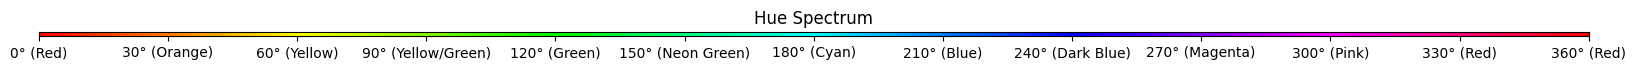

In [11]:
# Generate a spectrum of hues
hues = np.linspace(0, 1, 360)  # 360 values corresponding to hue angles
saturation = np.ones_like(hues)
value = np.ones_like(hues)

# Convert HSV to RGB
hsv_colors = np.stack([hues, saturation, value], axis=1)
rgb_colors = mcolors.hsv_to_rgb(hsv_colors)

# Plot the spectrum
plt.figure(figsize=(20, 2))
plt.imshow([rgb_colors], extent=[0, 360, 0, 1])
plt.yticks([])
plt.xticks(np.arange(0, 361, 30), labels=[
    "0° (Red)", "30° (Orange)", "60° (Yellow)", "90° (Yellow/Green)",
    "120° (Green)", "150° (Neon Green)", "180° (Cyan)", "210° (Blue)",
    "240° (Dark Blue)", "270° (Magenta)", "300° (Pink)", "330° (Red)", "360° (Red)"
])
plt.title("Hue Spectrum")
plt.show()


### Counting Colors

In [12]:
def classify_color_by_tone(hsv):
    hue = hsv[0] * 360  # Convert hue from [0, 1] to [0, 360]
    
    if hue < 30 or hue >= 330:
        return 'red'
    elif 30 <= hue < 60:
        return 'orange'
    elif 60 <= hue < 90:
        return 'yellow'
    elif 90 <= hue < 120:
        return 'yellow/green'
    elif 120 <= hue < 150:
        return 'green'
    elif 150 <= hue < 180:
        return 'neon green'
    elif 180 <= hue < 210:
        return 'cyan'
    elif 210 <= hue < 240:
        return 'blue'
    elif 240 <= hue < 270:
        return 'dark blue'
    elif 270 <= hue < 300:
        return 'magenta'
    elif 300 <= hue < 330:
        return 'pink'
    else:
        return 'unknown'

# Convert the RGB cluster centers to HSV and classify them by tone
color_tones = [classify_color_by_tone(mcolors.rgb_to_hsv([r/255, g/255, b/255])) for r, g, b in all_cluster_centers]

# Count the occurrences of each tone
tone_counts = Counter(color_tones)

# Calculate the percentage of each tone
total_colors = len(all_cluster_centers)
tone_percentages = {tone: (count / total_colors) * 100 for tone, count in tone_counts.items()}

# Display the results
for tone, percentage in tone_percentages.items():
    print(f"{tone.capitalize()} tones: {percentage:.2f}%")


Blue tones: 9.01%
Orange tones: 24.18%
Red tones: 31.82%
Cyan tones: 12.05%
Yellow tones: 8.28%
Neon green tones: 5.43%
Yellow/green tones: 3.36%
Magenta tones: 0.55%
Dark blue tones: 1.98%
Pink tones: 0.78%
Green tones: 2.57%


### Sanity Check

In [13]:
# Sanity check: Ensure total counts match the number of colors
total_count = sum(tone_counts.values())
if total_count == total_colors:
    print("All colors are accounted for.")
else:
    print(f"Warning: Mismatch in total counts. Expected {total_colors}, but got {total_count}.")

# Check for any "unknown" classifications
if 'unknown' in tone_counts:
    print(f"Warning: {tone_counts['unknown']} colors are classified as 'unknown'.")
else:
    print("No colors are classified as 'unknown'.")

# Print a sample of classified colors
print("Sample of classified colors:")
sample_size = min(10, len(all_cluster_centers))  # Adjust sample size as needed
for i in range(sample_size):
    r, g, b = all_cluster_centers[i]
    hsv = mcolors.rgb_to_hsv([r/255, g/255, b/255])
    tone = classify_color_by_tone(hsv)
    print(f"Color RGB({r}, {g}, {b}) -> HSV({hsv[0]*360:.2f}°, {hsv[1]:.2f}, {hsv[2]:.2f}) -> Tone: {tone}")

# Display the summary of counts and percentages
print("\nSummary of tone counts and percentages:")
for tone, count in tone_counts.items():
    percentage = tone_percentages[tone]
    print(f"{tone.capitalize()}: {count} colors ({percentage:.2f}%)")


All colors are accounted for.
No colors are classified as 'unknown'.
Sample of classified colors:
Color RGB(111.38709677419355, 133.2258064516129, 161.74193548387095) -> HSV(213.98°, 0.31, 0.63) -> Tone: blue
Color RGB(78.3269230769231, 68.02884615384617, 56.394230769230745) -> HSV(31.83°, 0.28, 0.31) -> Tone: orange
Color RGB(139.4107142857143, 134.17857142857144, 121.19642857142857) -> HSV(42.76°, 0.13, 0.55) -> Tone: orange
Color RGB(199.4677419354838, 186.66129032258067, 174.0161290322581) -> HSV(29.81°, 0.13, 0.78) -> Tone: red
Color RGB(27.038461538461505, 23.5512820512821, 19.897435897435955) -> HSV(30.70°, 0.26, 0.11) -> Tone: orange
Color RGB(113.3716814159292, 110.929203539823, 101.84955752212389) -> HSV(47.28°, 0.10, 0.44) -> Tone: orange
Color RGB(74.15094339622644, 81.26415094339623, 96.0) -> HSV(220.47°, 0.23, 0.38) -> Tone: blue
Color RGB(152.58035714285717, 151.83035714285717, 147.4642857142857) -> HSV(51.20°, 0.03, 0.60) -> Tone: orange
Color RGB(49.61818181818184, 40.

### Final K-Means Clustering

Lets now do a K_Means analysis on all of our colors (that we got using K_Means on each segment of each movie) to get a set of 15/20 colors to represent english film.

In [16]:
# Define the number of final clusters 
final_num_clusters = 20 

# Perform the final K-Means clustering on the combined cluster centers
final_kmeans = KMeans(n_clusters=final_num_clusters, n_init=10, random_state=42)
final_kmeans.fit(all_cluster_centers)

# Get the final cluster centers (representing the dominant colors)
final_colors = final_kmeans.cluster_centers_

### Visualization

In [17]:
# Convert RGB values to HEX
final_hex_colors = [mcolors.to_hex([r/255, g/255, b/255]) for r, g, b in final_colors]

# Optional: Sort the final colors by hue to make them more visually organized
hsv_colors = [mcolors.rgb_to_hsv([r/255, g/255, b/255]) for r, g, b in final_colors]
sorted_indices = sorted(range(len(hsv_colors)), key=lambda i: (hsv_colors[i][0], hsv_colors[i][1], hsv_colors[i][2]))
sorted_final_hex_colors = [final_hex_colors[i] for i in sorted_indices]

# Set the number of columns for the grid display
num_columns = 5  # Adjust as needed

# Calculate the number of rows needed
num_rows = math.ceil(len(sorted_final_hex_colors) / num_columns)

# Create an HTML table with a grid layout
html_table = '<table style="border-collapse: collapse;">'
for i in range(num_rows):
    html_table += '<tr>'
    for j in range(num_columns):
        index = i * num_columns + j
        if index < len(sorted_final_hex_colors):
            hex_color = sorted_final_hex_colors[index]
            html_table += f'<td style="background-color:{hex_color}; width:50px; height:25px; border: 1px solid #ccc;"></td>'
            html_table += f'<td style="padding: 5px;">{hex_color}</td>'
    html_table += '</tr>'
html_table += '</table>'

# Display the HTML table with the final colors
display(HTML(html_table))

,#a1513b,,#4e3a2c,,#9d7b63,,#171512,,#604f3d
,#302a23,,#7a6b54,,#cba061,,#bbac93,,#989383
,#c5c3b5,,#767976,,#d7dcd8,,#5a605e,,#9ea5a5
,#43768b,,#8ab4cc,,#39474f,,#798c98,,#4c66cf
